<a href="https://colab.research.google.com/github/larissavaladao/time_series_curuai/blob/main/4.TSS_modeling/2.TSS_ml_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import packages

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
import os


from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import PredictionErrorDisplay
from sklearn.svm import SVR
from sklearn import ensemble

In [3]:
#uncomment the following lines if using Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

# Export directory

In [4]:
# export_dir = r'C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\TSS Modeling'
export_dir ='/content/TSS Modeling'
os.makedirs(export_dir, exist_ok=False)

# Import Data

In [5]:
# import directory
# data_directory = r'C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Landsat Sampling\Merged Landsat Data'
data_directory = '/content'

In [6]:
# import data as dataframe
df = pd.read_csv(os.path.join(data_directory,'min_date.csv'))
df = df.drop(columns=['Unnamed: 0', 'CHLOROPHYLL',
                      'CHLOROPHYLL_B', 'DOC', 'dif_date_point',
                      'N_TOTAL', 'N_TOTAL_DISSOLVED',
                      'POC', 'P_ORGANIC', 'P_TOTAL',
                      'SILICA',  'TOC', 'duplicated'],axis=1).rename(columns={'SPM':"TSS"})
df.columns

Index(['CHLOROPHYLL_A', 'CLOUD_COVER', 'DEPTH_CLASS', 'ID', 'LATITUDE',
       'LOCATION', 'LONGITUDE', 'MISSION', 'SAMPLE_SITE', 'SAMPLING_DEPTH',
       'TSS', 'TOTAL_DEPTH', 'TURBIDITY', 'WATER_PERIOD', 'blue_max',
       'blue_mean', 'blue_median', 'blue_min', 'blue_stdDev', 'count_pixel',
       'datetime', 'green_max', 'green_mean', 'green_median', 'green_min',
       'green_stdDev', 'img_date', 'nir_max', 'nir_mean', 'nir_median',
       'nir_min', 'nir_stdDev', 'red_max', 'red_mean', 'red_median', 'red_min',
       'red_stdDev', 'system_index', 'dif_date_point_abs', 'satellite'],
      dtype='object')

# Model Evaluation Functions

In [7]:
def model_metrics(y_true,y_pred):
    ''' y = observed target values
    y_pred = predicted target values'''
    from sklearn.metrics import r2_score
    from sklearn.metrics import mean_absolute_error
    from sklearn.metrics import mean_squared_error
    from sklearn.metrics import mean_absolute_percentage_error
    from sklearn.metrics import explained_variance_score

    return {'r2':r2_score(y_true, y_pred),
'mae':mean_absolute_error(y_true, y_pred),
'mse':mean_squared_error(y_true, y_pred),
'mape':mean_absolute_percentage_error(y_true, y_pred),
'exp_var': explained_variance_score(y_true, y_pred)
    }

In [8]:
def cv_model_metrics(model,X,y,n_cv=20):
    ''' model = model to evaluate
    X = predictors
    y = observed target values
    cv = number of cross validations, standard is 5'''
    from sklearn.model_selection import ShuffleSplit

    cv = ShuffleSplit(n_splits=n_cv, test_size=0.15, random_state=666)
    from sklearn.model_selection import cross_val_score

    return {'r2':float(abs(cross_val_score(model, X, y, cv=cv,scoring='r2')).mean()),
'mae':float(abs(cross_val_score(model, X, y, cv=cv,scoring='neg_mean_absolute_error')).mean()),
'mse':float(abs(cross_val_score(model, X, y, cv=cv,scoring='neg_mean_squared_error')).mean()),
'mape':float(abs(cross_val_score(model, X, y, cv=cv,scoring='neg_mean_absolute_percentage_error')).mean()),
'exp_var':float( abs(cross_val_score(model, X, y, cv=cv,scoring='explained_variance')).mean())
    }

# Helper functions

**Helper Functions**
1. **`plot_evaluation()`** - Standardizes residual and prediction error plots
2. **`prepare_time_series_plot()`** - Creates consistent time-series visualizations with metrics
3. **`train_and_evaluate_model()`** - Unified training, evaluation, and plotting pipeline
4. **`transform_dataframe()`** - Transform results dictionary to dataframe
5. **`feature_importance_plot()`** - plot feature importances for GBR and RF

In [9]:
def plot_evaluation(y_true, y_pred, title="Model Evaluation",exp="Residuals"):
    """Create residual and prediction error plots."""
    fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
    PredictionErrorDisplay.from_predictions(
        y_true,
        y_pred=y_pred,
        kind="actual_vs_predicted",
        ax=axs[0]
    )
    axs[0].set_title("Actual vs. Predicted values")
    PredictionErrorDisplay.from_predictions(
        y_true,
        y_pred=y_pred,
        kind="residual_vs_predicted",
        ax=axs[1]
    )
    axs[1].set_title("Residuals vs. Predicted Values")
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(os.path.join(export_dir,f"res_{exp}.jpg"),dpi=300)
    plt.show()
    plt.close()

In [10]:
def prepare_time_series_plot(df, y_pred, cv_metrics_dict, title, r2_key='mae',exp="TimeSeries", color_palette = None):
    """Create time series plot with predictions and observations."""
    fig, ax = plt.subplots(figsize=(16, 6))

    # Plot predictions
    ax.plot(df['datetime'], y_pred,
            color='gray', marker='x', linestyle='solid', linewidth=2, label='Predicted Model')

    # Define colors for water periods
    water_periods = sorted(df['WATER_PERIOD'].unique())
    if color_palette == None:
        color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728' ]

    colors = {period: color_palette[i % len(color_palette)] for i, period in enumerate(water_periods)}

    # Plot observations by water period
    for water_period in water_periods:
        subset = df[df['WATER_PERIOD'] == water_period]
        ax.plot(subset['datetime'], subset['TSS'],
                marker='o', markersize=6, alpha=0.5,
                color=colors[water_period], linestyle='none',
                label=f'{water_period}')
    # Set x-ticks
    total_len = len(y_pred)
    ticks = np.arange(0, total_len, 20)
    tick_labels = [df['date'].iloc[t] if t < len(df) else '' for t in ticks]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels)

    # Add metrics text box
    # add sample size info
    if cv_metrics_dict and r2_key in cv_metrics_dict:
        r2 = round(float(cv_metrics_dict[r2_key]), 4)
        r2_str = f'MAE = {r2}'
        samples = f"Sample size: {total_len}"
        ax.text(0.05, 0.95, f"{r2_str}\n{samples}", transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    ax.set_xlabel('Date')
    ax.set_ylabel('TSS (mg/L)')
    ax.set_title(title)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig(os.path.join(export_dir,f"{exp}.jpg"),dpi=300)
    plt.show()
    plt.close()

In [32]:
def feature_importance_plot(model_fit,bands,exp="FeatureImportance"):
    """Plot feature importance"""

    feature_importance = model_fit.best_estimator_.feature_importances_
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + 0.5
    fig = plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.barh(pos, feature_importance[sorted_idx], align="center")
    plt.yticks(pos, np.array(bands)[sorted_idx]) # Sort bands using sorted_idx
    plt.title("Feature Importance (MDI)")

    plt.tight_layout()
    plt.savefig(os.path.join(export_dir,f"feat_imp_{exp}.jpg"),dpi=300)
    plt.show()
    plt.close()

In [12]:
def transform_dataframe(results):
    """Export metrics and cv_metrics dataframes to CSV files."""
    # Lists to store the flattened data
    metrics_list = []
    cv_metrics_list = []
    # Iterate through the results dictionary
    for model_key, groups in results['water_period']['model'].items():
        for group_key, features in groups.items():
            for feature_key, data in features.items():
                # Check if data exists (in case some weren't run)
                if not data:
                    continue

                # 1. Process Standard Metrics
                # Create a copy of the metrics dictionary to avoid modifying the original
                row_metrics = data['metrics'].copy()
                # Add identifiers
                row_metrics['Model'] = model_key
                row_metrics['Group'] = group_key
                row_metrics['Feature'] = feature_key
                row_metrics['Params'] = data['params']
                metrics_list.append(row_metrics)

                # 2. Process CV Metrics
                row_cv = data['cv_metrics'].copy()
                # Add identifiers
                row_cv['Model'] = model_key
                row_cv['Group'] = group_key
                row_cv['Feature'] = feature_key
                row_cv['Params'] = data['params']
                cv_metrics_list.append(row_cv)

    # Create DataFrames
    df_metrics = pd.DataFrame(metrics_list)
    df_cv_metrics = pd.DataFrame(cv_metrics_list)

    # Reorder columns for better readability (Identifiers first)
    cols_order = ['Model', 'Group', 'Feature','Params']
    # Get the remaining metric columns dynamically
    metric_cols = [c for c in df_metrics.columns if c not in cols_order]
    cv_metric_cols = [c for c in df_cv_metrics.columns if c not in cols_order]

    df_metrics = df_metrics[cols_order + metric_cols]
    df_cv_metrics = df_cv_metrics[cols_order + cv_metric_cols]

    # Display the first few rows
    print("Standard Metrics DataFrame:")
    display(df_metrics.head())
    print("\nCross-Validation Metrics DataFrame:")
    display(df_cv_metrics.head())

    return df_metrics, df_cv_metrics

In [13]:
# Plot styling
PLOT_CONFIG = {
        'palette': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728' ]
    }
def train_and_evaluate_model(model, X, y, model_name, df_data=None, title=None,exp = None,impPlot =None):
    """Train model, evaluate, and optionally plot results."""
    # Fit and predict
    model_fit = model.fit(X, y)
    y_pred = model_fit.predict(X)

    # Calculate metrics
    metrics = model_metrics(y, y_pred)
    cv_metrics = cv_model_metrics(model_fit.best_estimator_, X, y, n_cv=20)

    print(f"\n{'='*50}")
    print(f"{model_name} Results")
    print(f"{'='*50}")
    print(f"Training Metrics: {metrics}")
    print(f"CV Metrics: {cv_metrics}")

    # Plot evaluation
    plot_evaluation(y, y_pred, title=f"{model_name} - Model Evaluation", exp = exp)

    # Plot time series if data provided
    if df_data is not None and title is not None:
        prepare_time_series_plot(df_data, y_pred, cv_metrics, title, exp = exp, color_palette = PLOT_CONFIG['palette'])
    if impPlot in ['RF','GBR']:
        feature_importance_plot(model_fit, X.columns, exp = exp)

    return model_fit, y_pred, metrics, cv_metrics

# Model Configuration

In [14]:
# Central model definitions
MODEL_CONFIG = {
    'KRR': {
        'model': GridSearchCV(
    KernelRidge(),
    param_grid={'kernel':['additive_chi2', 'chi2', 'linear', 'poly', 'polynomial', 'rbf', 'laplacian', 'sigmoid', 'cosine'],"alpha": [1.5,1e0, 0.1, 1e-2, 1e-3], "gamma": [None,1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02],'degree':[2,3,4]},
    scoring=['r2',
'neg_mean_absolute_error',
'neg_mean_squared_error',
'neg_mean_absolute_percentage_error',
'explained_variance'],
    refit = 'neg_mean_absolute_percentage_error',
    cv = 15
),
        'description': 'Kernel ridge regression (KRR)'
    },
    'SVM': {
        'model': GridSearchCV(
    SVR(kernel='polynomial'),
    param_grid={'kernel':['sigmoid', 'poly', 'rbf'],
                "coef0": [0.5,1],
                'C':[1e0, 1e1, None],
                "gamma": ['scale','auto',None],
                'degree':[2,3,4]},
    scoring=['r2',
'neg_mean_absolute_error',
'neg_mean_squared_error',
'neg_mean_absolute_percentage_error',
'explained_variance'],
    refit = 'neg_mean_absolute_percentage_error',
    cv = 15
),
        'description': 'Support Vector Regression'
    },
    'GBR': {
        'model': GridSearchCV(
    ensemble.GradientBoostingRegressor(n_iter_no_change=100,random_state=100),
    param_grid={'loss':['absolute_error', 'huber','squared_error',],
                'learning_rate':[0.01,0.1,1],
                'n_estimators':[100,300,500],
                'max_depth':[None,2,5,10],
                'warm_start':[True,False]
                },
    scoring=['r2',
'neg_mean_absolute_error',
'neg_mean_squared_error',
'neg_mean_absolute_percentage_error',
'explained_variance'],
    refit = 'neg_mean_absolute_percentage_error',
    cv = 15
),
        'description': 'Gradient Boosting Regression'
    },
    'RF': {
        'model': GridSearchCV(
    ensemble.RandomForestRegressor(n_estimators=200,random_state=100),
    param_grid={'criterion':['absolute_error', 'squared_error'],
                'max_depth':[None,2,5,10],
                'max_features':["sqrt","log2"],
                'n_estimators':[100,200,300,500],
                'oob_score':[False,True],
                'warm_start':[True,False]
                },
    scoring=['r2',
'neg_mean_absolute_error',
'neg_mean_squared_error',
'neg_mean_absolute_percentage_error',
'explained_variance'],
    refit = 'neg_mean_absolute_percentage_error',
    cv = 15
),
        'description': 'Random Forest Regression'
    }
}

In [15]:
def get_model(model_name):
    """
    Get model by name.
    Usage
    model_poly = get_model('polynomial')
    model_splines = get_model('splines')
    """
    return MODEL_CONFIG[model_name]['model']

In [16]:
FEATURE_GROUPS = {
    'multi_band': {
        'nir_red': {'band': ['nir_mean', 'red_mean'],
                    'name': 'NIR and RED'},
        'nir_red_green': {'band': ['nir_mean', 'red_mean', 'green_mean'],
                    'name': 'NIR, RED and GREEN'},
        'all_bands': {'band': ['blue_mean', 'green_mean', 'red_mean', 'nir_mean'],
                      'name': 'All bands'},
        'location': {'band': ['blue_mean', 'green_mean', 'red_mean', 'nir_mean','LOC'],
                      'name': 'All bands + Lake'},
        'period': {'band': ['blue_mean', 'green_mean', 'red_mean', 'nir_mean','PERIOD'],
                      'name': 'All bands + Water Period'},
        'period_location': {'band': ['blue_mean', 'green_mean', 'red_mean', 'nir_mean','PERIOD','LOC'],
                      'name': 'All bands + Water Period + Location'}
    }
}

# Usage
# X_nir_red = df_subset[FEATURE_GROUPS['multi_band']['nir_red']]

# Results Dictionary

In [17]:
results = {
    'water_period': {
        'period_filter':None,
        'model':{'KRR': {
            'multi_band': {
                'nir_red': {},
                'nir_red_green': {},
                'all_bands': {},
                'location':{},
                'period': {},
                'period_location': {}
                }
            },
            'SVM': {
            'multi_band': {
                'nir_red': {},
                'nir_red_green': {},
                'all_bands': {},
                'location':{},
                'period': {},
                'period_location': {}
            }
        },
        'GBR': {
            'multi_band': {
                'nir_red': {},
                'nir_red_green': {},
                'all_bands': {},
                'location':{},
                'period': {},
                'period_location': {}
            }
        },
        'RF': {
            'multi_band': {
                'nir_red': {},
                'nir_red_green': {},
                'all_bands': {},
                'location':{},
                'period': {},
                'period_location': {}
            }
        }
        }
    }
}

# TSS

## Data Preparation

In [18]:
# filter parameters that will be used in the models
df_subset = df[['TSS','blue_mean',
       'green_mean',
       'nir_mean',
       'red_mean',
       'datetime',
       'WATER_PERIOD',
       'LOCATION']].copy()
# remove empty values
df_subset = df_subset.dropna()
df_subset.isna().sum()

,0
TSS,0
blue_mean,0
green_mean,0
nir_mean,0
red_mean,0
datetime,0
WATER_PERIOD,0
LOCATION,0


In [19]:
# obtain date from datetime
df_subset['date'] = df_subset['datetime'].apply(lambda row: row[:10])

In [20]:
n = 0
df_subset['LOC'] = df_subset['LOCATION'].copy()
for i in df_subset['LOCATION'].unique():
    df_subset['LOC'] = df_subset['LOC'].replace(i,n)
    n += 1

df_subset["LOC"] = df_subset["LOC"].astype('int8')

/tmp/ipython-input-3041617090.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_subset['LOC'] = df_subset['LOC'].replace(i,n)


In [21]:
n = 0
df_subset['PERIOD'] = df_subset['WATER_PERIOD'].copy()
for i in df_subset['WATER_PERIOD'].unique():
    df_subset['PERIOD'] = df_subset['PERIOD'].replace(i,n)
    n += 1

df_subset["PERIOD"] = df_subset["PERIOD"].astype('int8')

/tmp/ipython-input-2258988468.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_subset['PERIOD'] = df_subset['PERIOD'].replace(i,n)


# Fit model with all data

In [22]:
y = df_subset['TSS'].copy()

## Kernel ridge regression (KRR)

https://scikit-learn.org/stable/modules/kernel_ridge.html

Kernel ridge regression (KRR)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254:


Kernel ridge regression (KRR) - NIR and RED Results
Training Metrics: {'r2': 0.7880707580723966, 'mae': 20.06984573627726, 'mse': 1074.1533056104583, 'mape': 0.4133265441495718, 'exp_var': 0.7880707580724692}
CV Metrics: {'r2': 0.6974871892780415, 'mae': 20.37651102348479, 'mse': 1132.0093088118624, 'mape': 0.42449824448513696, 'exp_var': 0.7054098588953926}


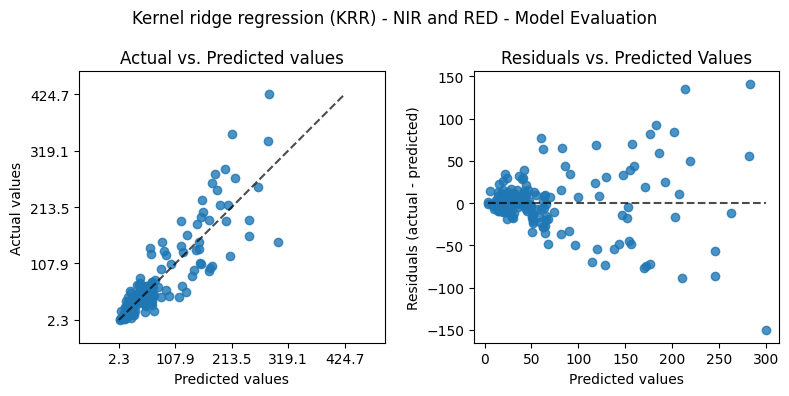

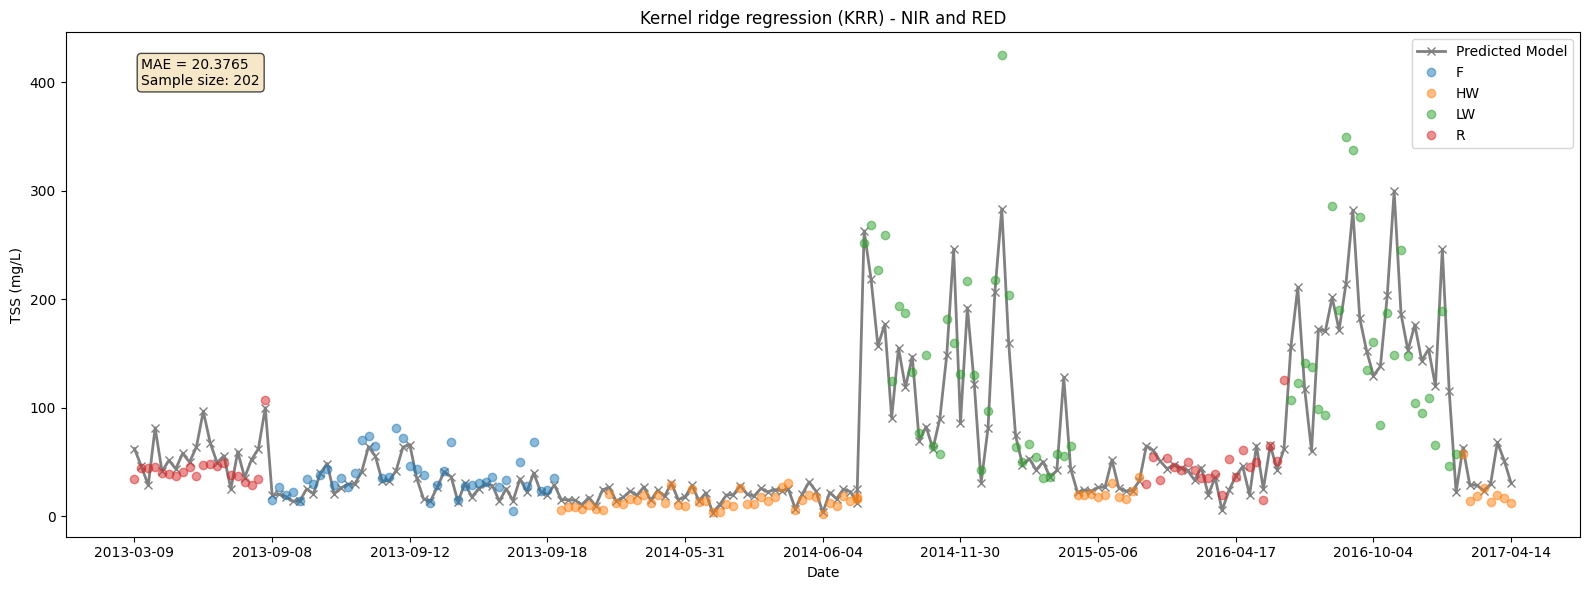

Kernel ridge regression (KRR)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254:


Kernel ridge regression (KRR) - NIR, RED and GREEN Results
Training Metrics: {'r2': 0.8103549824689729, 'mae': 16.42737341940518, 'mse': 961.2067717540092, 'mape': 0.3078989825411598, 'exp_var': 0.8199018834514202}
CV Metrics: {'r2': 0.5930706626740966, 'mae': 21.16817106245365, 'mse': 1651.4966132379955, 'mape': 0.3864430674584288, 'exp_var': 0.6271157365157121}


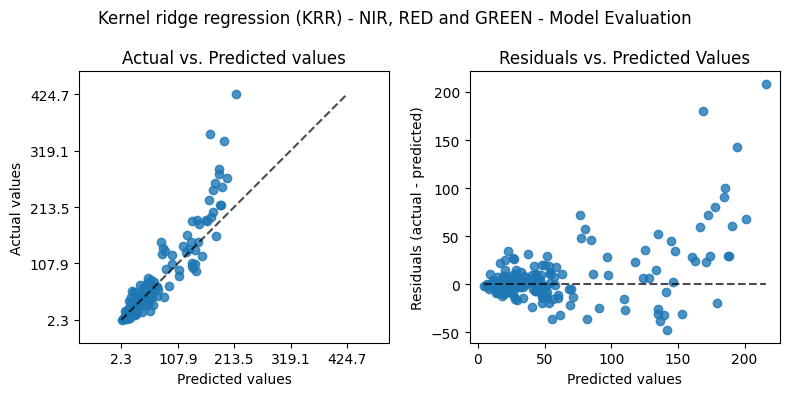

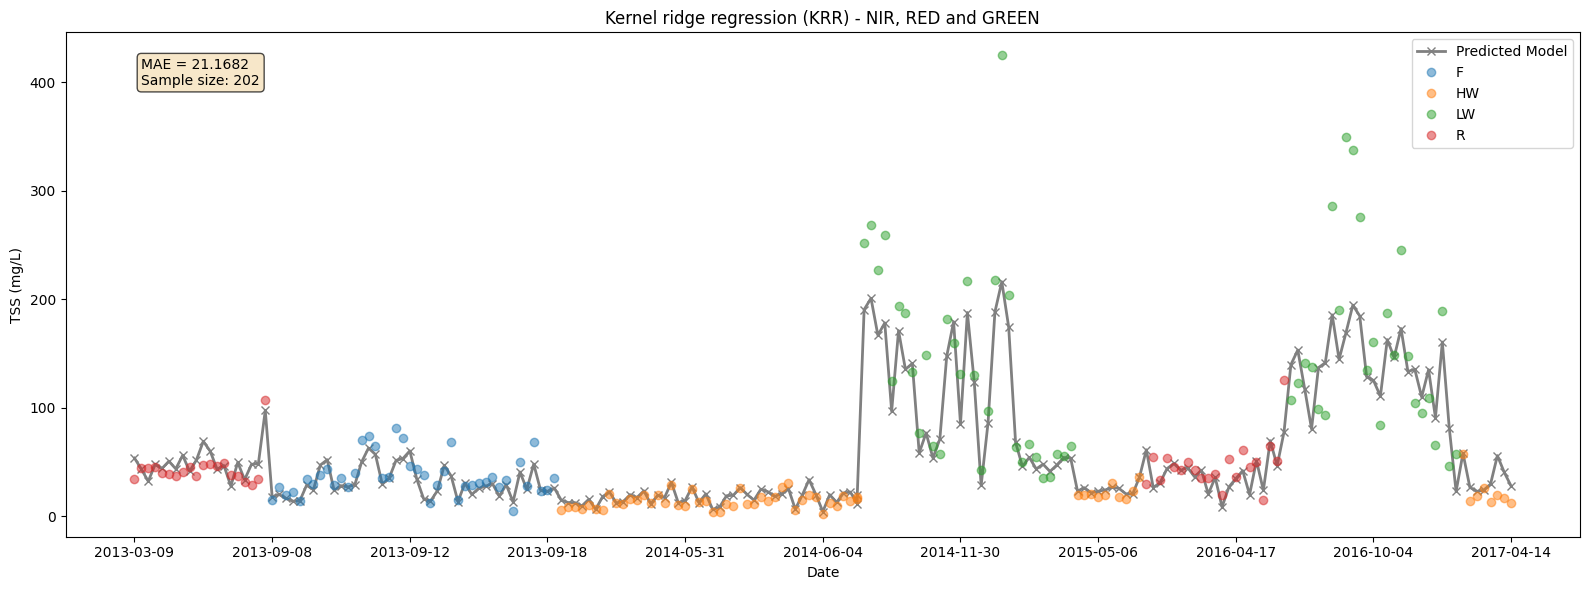

Kernel ridge regression (KRR)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254:


Kernel ridge regression (KRR) - All bands Results
Training Metrics: {'r2': 0.7956205837935442, 'mae': 15.879604138170667, 'mse': 1035.8873722197097, 'mape': 0.25938581694495666, 'exp_var': 0.8124538156845992}
CV Metrics: {'r2': 0.5347052676045699, 'mae': 21.730867731740176, 'mse': 1963.5557374227876, 'mape': 0.355595492517358, 'exp_var': 0.5900858200120689}


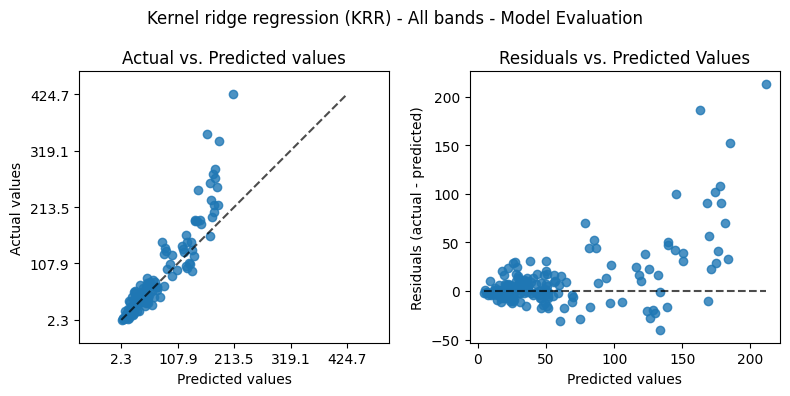

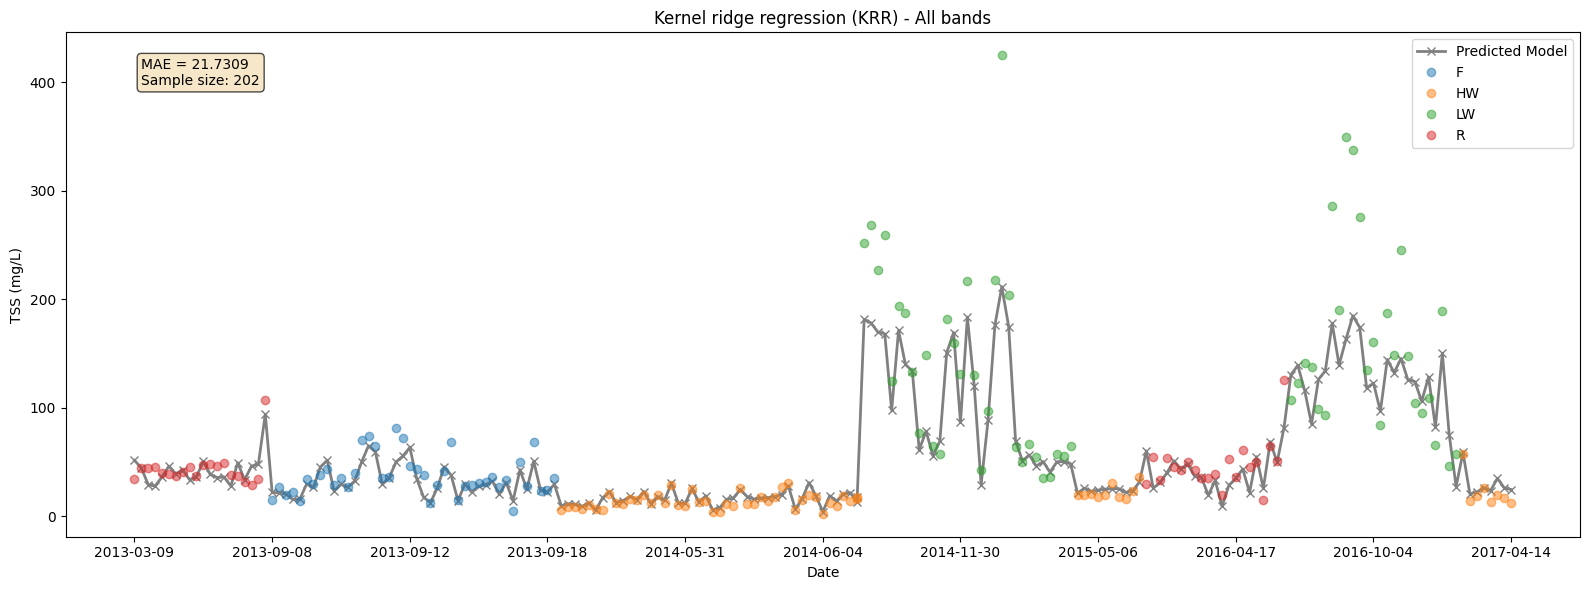

Kernel ridge regression (KRR)


A saída de streaming foi truncada nas últimas 5000 linhas.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Kernel ridge regression (KRR) - All bands + Lake Results
Training Metrics: {'r2': 0.7317652006432983, 'mae': 20.088437564862158, 'mse': 1359.5353514602996, 'mape': 0.33522074751256287, 'exp_var': 0.753315667841395}
CV Metrics: {'r2': 0.475500211283017, 'mae': 25.179296458171528, 'mse': 2096.2534800379217, 'mape': 0.42476551224832876, 'exp_var': 0.5310303075768787}


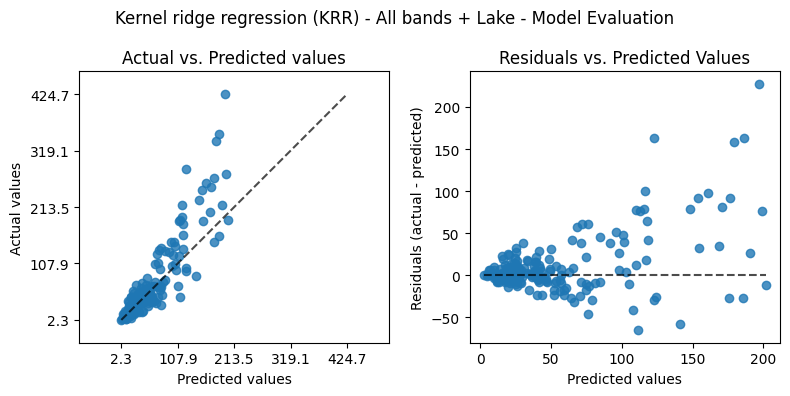

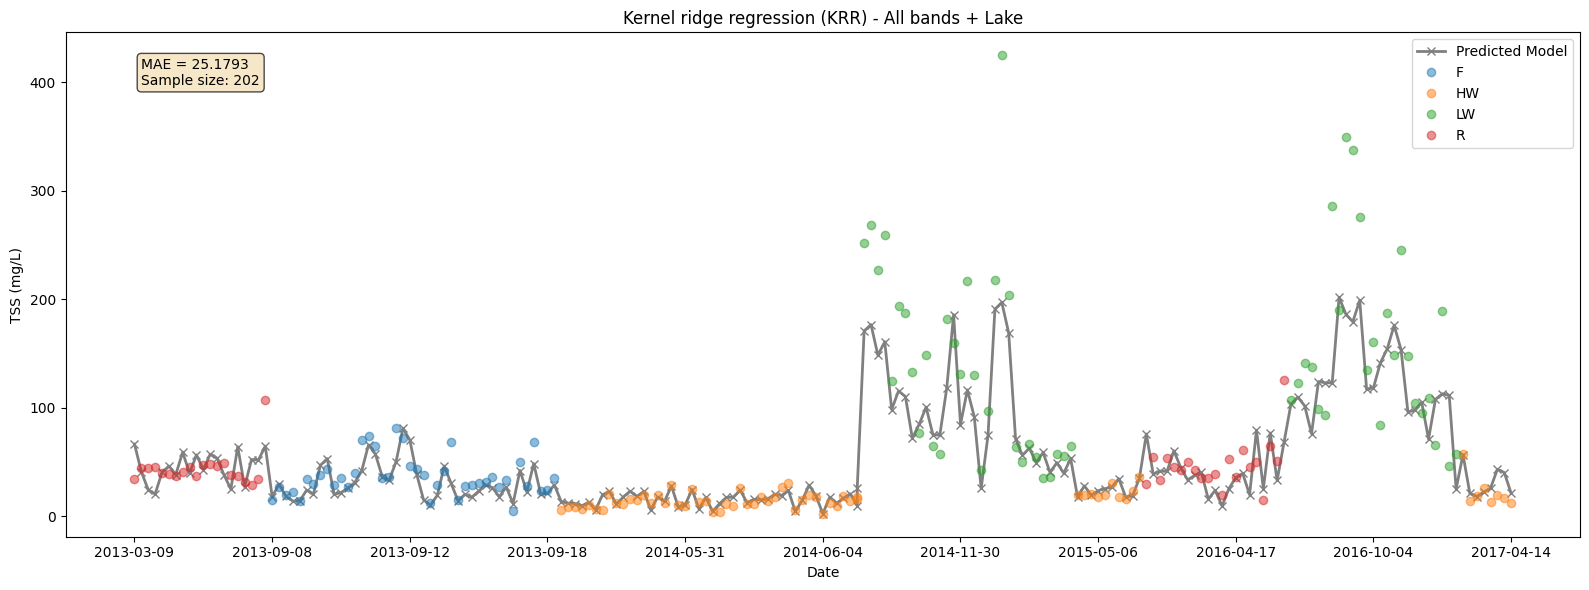

Kernel ridge regression (KRR)


A saída de streaming foi truncada nas últimas 5000 linhas.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Kernel ridge regression (KRR) - All bands + Water Period Results
Training Metrics: {'r2': 0.8042774527709421, 'mae': 16.946829663488653, 'mse': 992.0104426193806, 'mape': 0.28714094288936276, 'exp_var': 0.8042774648587822}
CV Metrics: {'r2': 0.6837907540063679, 'mae': 18.59688057809101, 'mse': 1147.1562164327288, 'mape': 0.32800123505236933, 'exp_var': 0.6824702105638992}


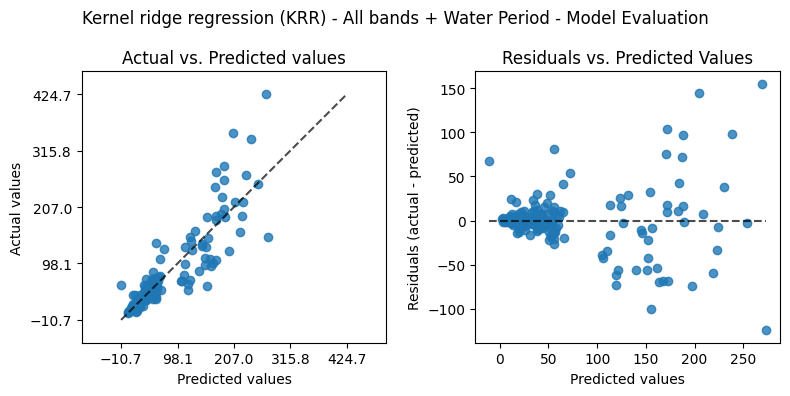

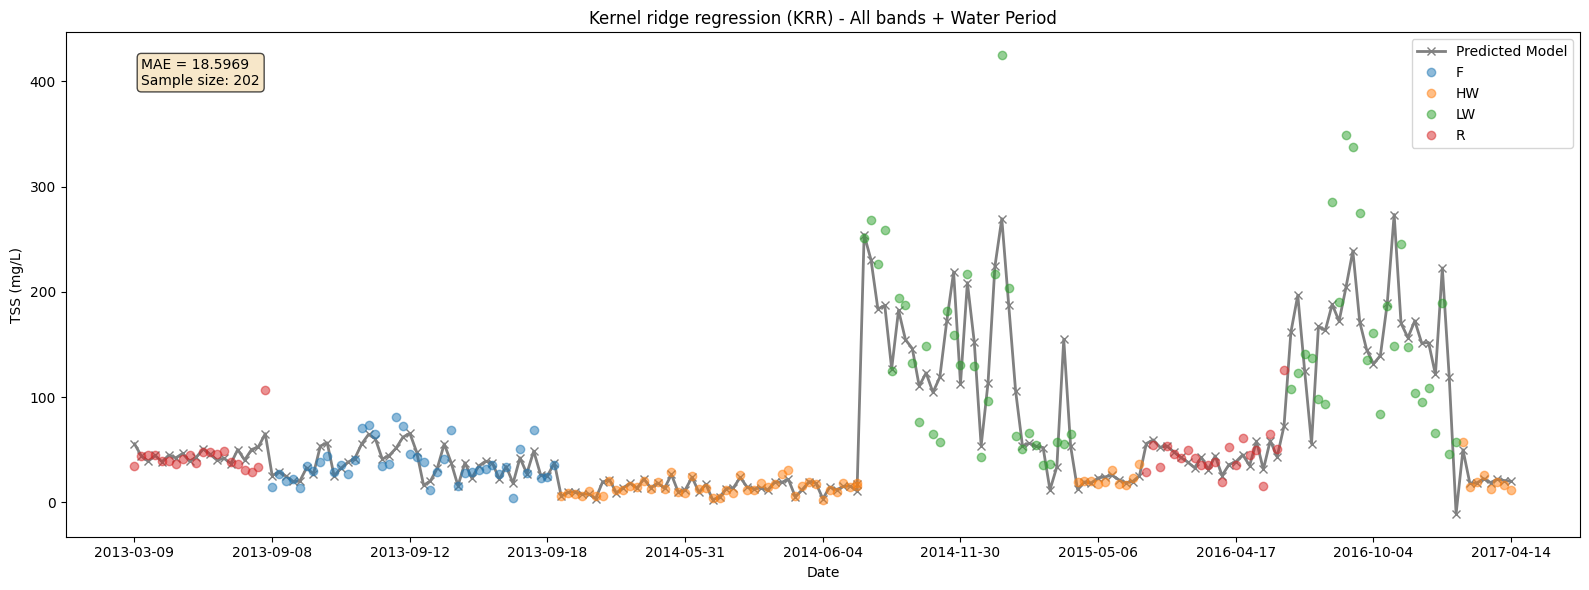

Kernel ridge regression (KRR)


A saída de streaming foi truncada nas últimas 5000 linhas.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Kernel ridge regression (KRR) - All bands + Water Period + Location Results
Training Metrics: {'r2': 0.9262308400075406, 'mae': 9.287855628915201, 'mse': 373.8954867071894, 'mape': 0.13878323963014022, 'exp_var': 0.9267141061621237}
CV Metrics: {'r2': 0.5433711205058834, 'mae': 23.06131148722388, 'mse': 1681.661498131531, 'mape': 0.38799549137730927, 'exp_var': 0.5889306346219476}


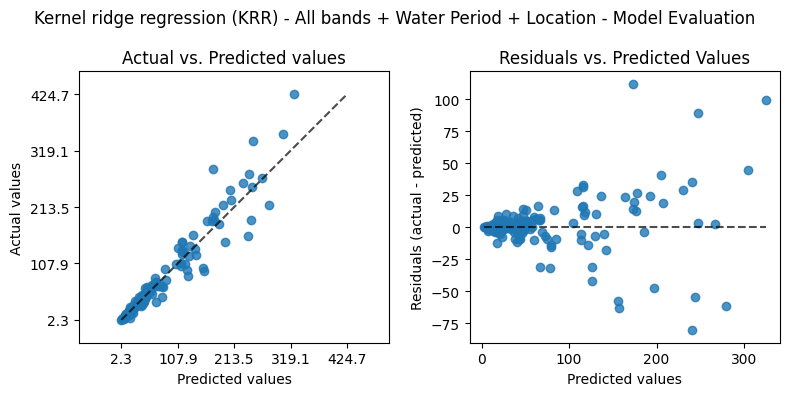

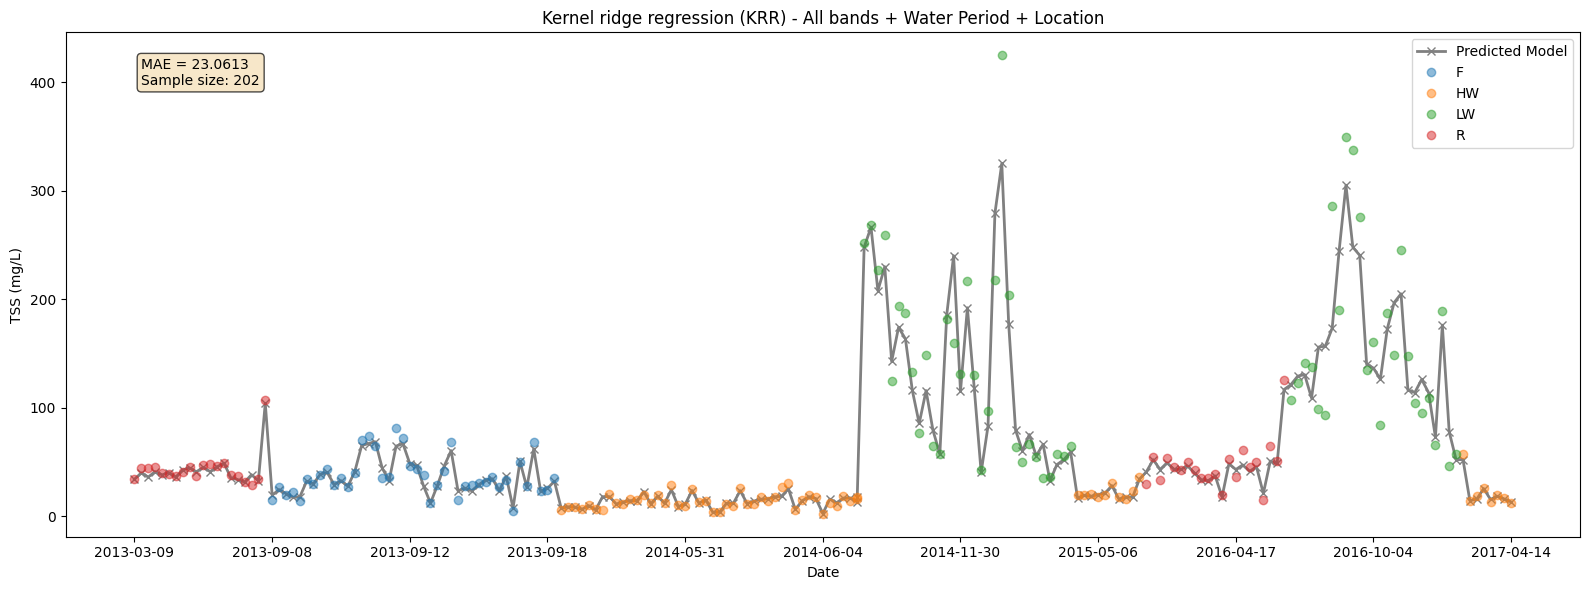

In [23]:
key = 'KRR'
n_bands = 'multi_band'
model = get_model(key)
title = (MODEL_CONFIG[key]['description'])
# Feature Exploration
for feature_key,feature_info in FEATURE_GROUPS[n_bands].items():

    band = feature_info['band']
    name = feature_info['name']

    X = df_subset[band].copy()
    print(title)

    model_fit, y_pred, metrics, cv_metrics = train_and_evaluate_model(
            model=model,
            X=X, y=y,
            model_name=f"{title} - {name}",
            title = f"{title} - {name}",
            df_data=df_subset,
            exp = f"{feature_key}_{key}",
            impPlot = key
        )

    results['water_period']['model'][key][n_bands][feature_key] = {'metrics': metrics,'cv_metrics': cv_metrics,'params': model_fit.best_params_}
    results['water_period']['period_filter'] = None

### Export data

In [24]:
df_metrics, df_cv_metrics = transform_dataframe(results)

Standard Metrics DataFrame:


,Model,Group,Feature,Params,r2,mae,mse,mape,exp_var
0,KRR,multi_band,nir_red,"{'alpha': 0.001, 'degree': 2, 'gamma': 100.0, ...",0.788071,20.069846,1074.153306,0.413327,0.788071
1,KRR,multi_band,nir_red_green,"{'alpha': 1.5, 'degree': 2, 'gamma': 100.0, 'k...",0.810355,16.427373,961.206772,0.307899,0.819902
2,KRR,multi_band,all_bands,"{'alpha': 1.5, 'degree': 2, 'gamma': 100.0, 'k...",0.795621,15.879604,1035.887372,0.259386,0.812454
3,KRR,multi_band,location,"{'alpha': 1.5, 'degree': 2, 'gamma': 100.0, 'k...",0.731765,20.088438,1359.535351,0.335221,0.753316
4,KRR,multi_band,period,"{'alpha': 0.001, 'degree': 2, 'gamma': 10.0, '...",0.804277,16.946830,992.010443,0.287141,0.804277



Cross-Validation Metrics DataFrame:


,Model,Group,Feature,Params,r2,mae,mse,mape,exp_var
0,KRR,multi_band,nir_red,"{'alpha': 0.001, 'degree': 2, 'gamma': 100.0, ...",0.697487,20.376511,1132.009309,0.424498,0.705410
1,KRR,multi_band,nir_red_green,"{'alpha': 1.5, 'degree': 2, 'gamma': 100.0, 'k...",0.593071,21.168171,1651.496613,0.386443,0.627116
2,KRR,multi_band,all_bands,"{'alpha': 1.5, 'degree': 2, 'gamma': 100.0, 'k...",0.534705,21.730868,1963.555737,0.355595,0.590086
3,KRR,multi_band,location,"{'alpha': 1.5, 'degree': 2, 'gamma': 100.0, 'k...",0.475500,25.179296,2096.253480,0.424766,0.531030
4,KRR,multi_band,period,"{'alpha': 0.001, 'degree': 2, 'gamma': 10.0, '...",0.683791,18.596881,1147.156216,0.328001,0.682470


In [25]:
df_metrics.to_csv(os.path.join(export_dir,'KRR_metrics.csv'))

df_cv_metrics.to_csv(os.path.join(export_dir,'KRR_cv_metrics.csv'))

## Suport Vectors Machine (SVM)

https://scikit-learn.org/stable/modules/svm.html

In [ ]:
key = 'SVM'
n_bands = 'multi_band'
model = get_model(key)
title = (MODEL_CONFIG[key]['description'])
# Feature Exploration
for feature_key,feature_info in FEATURE_GROUPS[n_bands].items():

    band = feature_info['band']
    name = feature_info['name']

    X = df_subset[band].copy()
    print(title)

    model_fit, y_pred, metrics, cv_metrics = train_and_evaluate_model(
            model=model,
            X=X, y=y,
            model_name=f"{title} - {name}",
            title = f"{title} - {name}",
            df_data=df_subset,
            exp = f"{feature_key}_{key}",
            impPlot = key
        )

    results['water_period']['model'][key][n_bands][feature_key] = {'metrics': metrics,'cv_metrics': cv_metrics,'params': model_fit.best_params_}
    results['water_period']['period_filter'] = None

### Export data

In [ ]:
df_metrics, df_cv_metrics = transform_dataframe(results)

In [ ]:
df_metrics.to_csv(os.path.join(export_dir,'SVM_metrics.csv'))

df_cv_metrics.to_csv(os.path.join(export_dir,'SVM_cv_metrics.csv'))

## Gradient Boosting (GBDT)

https://scikit-learn.org/stable/modules/ensemble.html#gradientboostingclassifier-and-gradientboostingregressor

In [ ]:
key = 'GBR'
n_bands = 'multi_band'
model = get_model(key)
title = (MODEL_CONFIG[key]['description'])
# Feature Exploration
for feature_key,feature_info in FEATURE_GROUPS[n_bands].items():

    band = feature_info['band']
    name = feature_info['name']

    X = df_subset[band].copy()
    print(title)

    model_fit, y_pred, metrics, cv_metrics = train_and_evaluate_model(
            model=model,
            X=X, y=y,
            model_name=f"{title} - {name}",
            title = f"{title} - {name}",
            df_data=df_subset,
            exp = f"{feature_key}_{key}",
            impPlot = key
        )

    results['water_period']['model'][key][n_bands][feature_key] = {'metrics': metrics,'cv_metrics': cv_metrics,'params': model_fit.best_params_}
    results['water_period']['period_filter'] = None

### Export data

In [ ]:
df_metrics, df_cv_metrics = transform_dataframe(results)

In [ ]:
df_metrics.to_csv(os.path.join(export_dir,'GBR_metrics.csv'))

df_cv_metrics.to_csv(os.path.join(export_dir,'GBR_cv_metrics.csv'))

## Random Forest Regressor

https://scikit-learn.org/stable/modules/ensemble.html#gradientboostingclassifier-and-gradientboostingregressor

### multiple bands

Random Forest Regression

Random Forest Regression - NIR and RED Results
Training Metrics: {'r2': 0.8972268355149218, 'mae': 14.33605026585992, 'mse': 520.900907093348, 'mape': 0.32140511135788413, 'exp_var': 0.8992282227782175}
CV Metrics: {'r2': 0.6746195236593236, 'mae': 21.51624361047107, 'mse': 1215.8214562063888, 'mape': 0.4622265701059828, 'exp_var': 0.683534898785995}


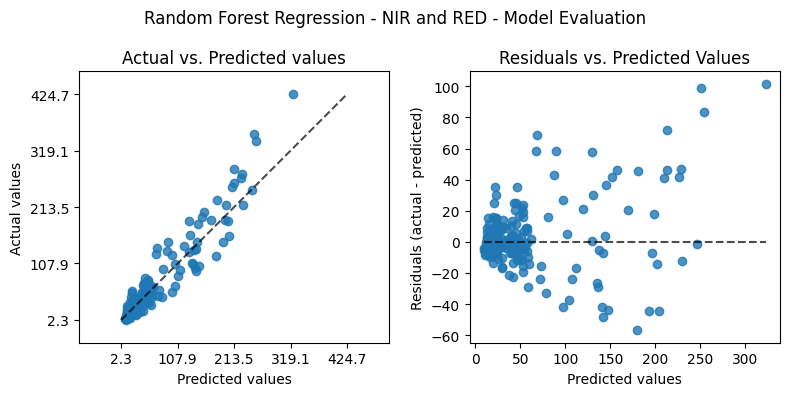

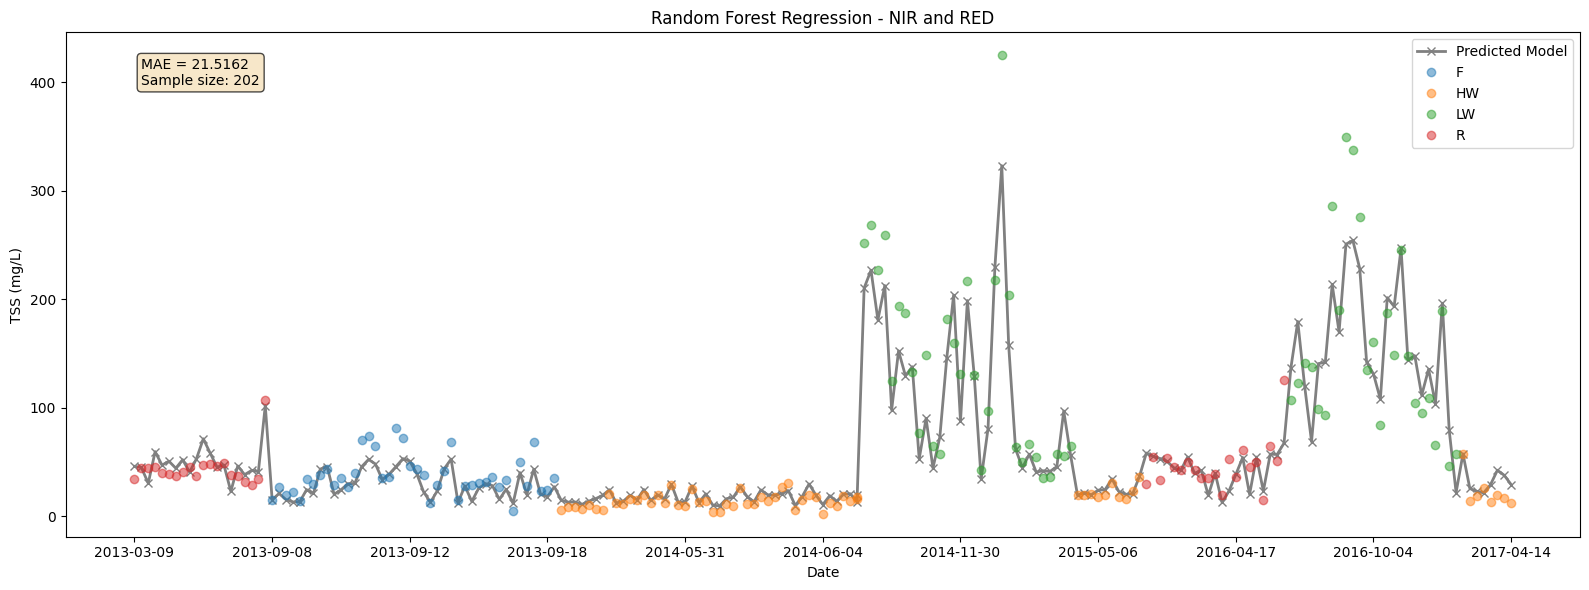

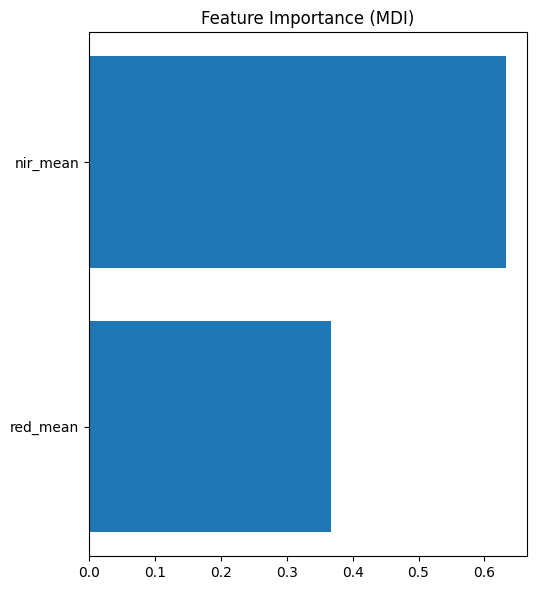

Random Forest Regression

Random Forest Regression - NIR, RED and GREEN Results
Training Metrics: {'r2': 0.8886117170930709, 'mae': 14.394853111739746, 'mse': 564.566225984159, 'mape': 0.2979152222482249, 'exp_var': 0.8904631984995978}
CV Metrics: {'r2': 0.6566933182935415, 'mae': 21.162913205965175, 'mse': 1327.2610088917354, 'mape': 0.4375472733672828, 'exp_var': 0.6659812718425513}


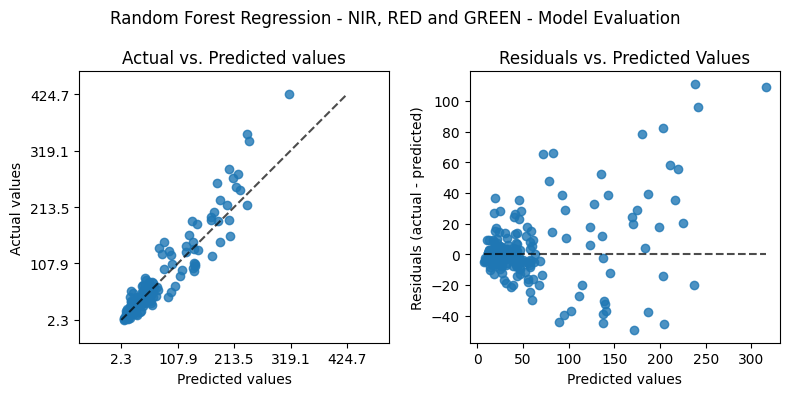

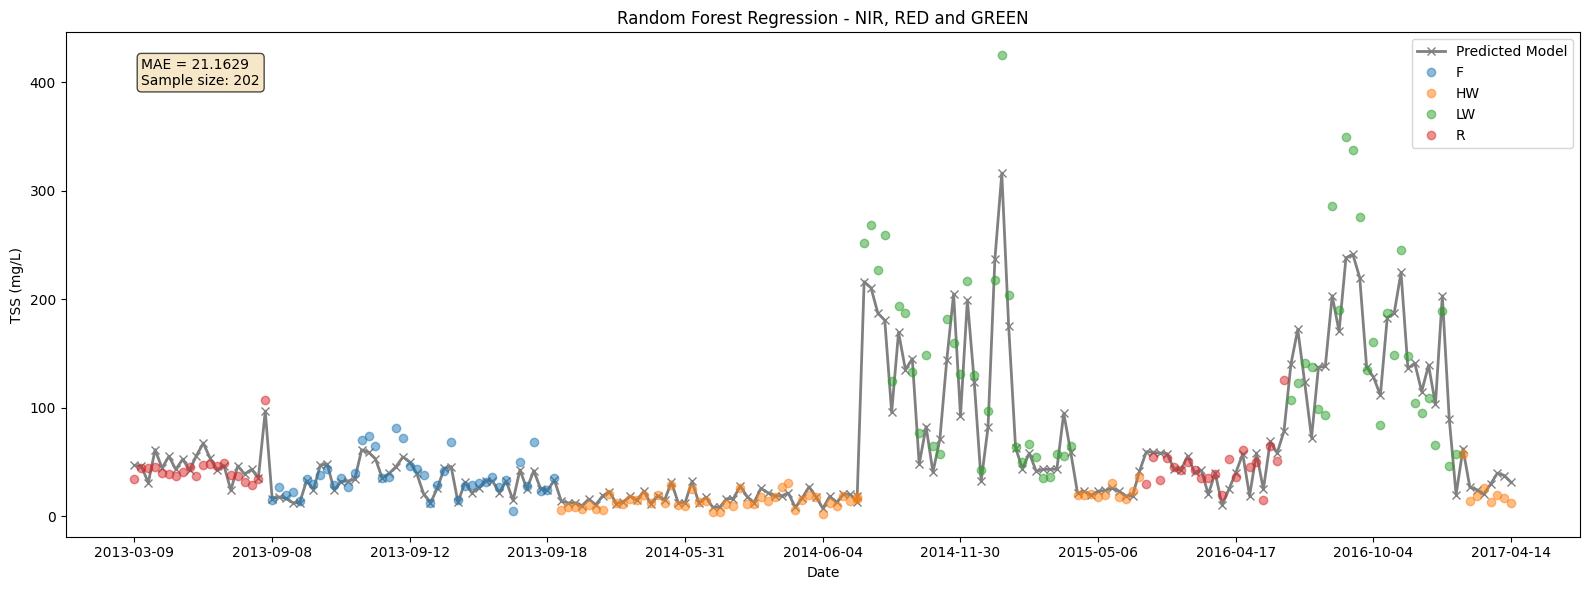

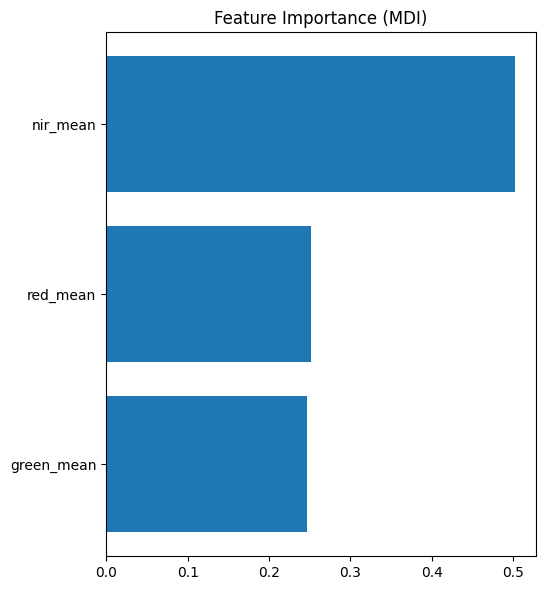

Random Forest Regression

Random Forest Regression - All bands Results
Training Metrics: {'r2': 0.9152077474442166, 'mae': 12.804609219314788, 'mse': 429.76550826367395, 'mape': 0.2885300636387399, 'exp_var': 0.91628995286627}
CV Metrics: {'r2': 0.6886980562262593, 'mae': 20.1210841963219, 'mse': 1214.5450344863077, 'mape': 0.43209563133279083, 'exp_var': 0.6970110880993147}


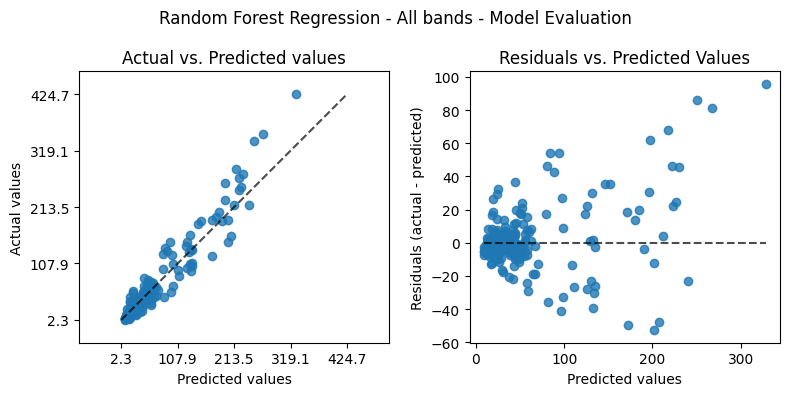

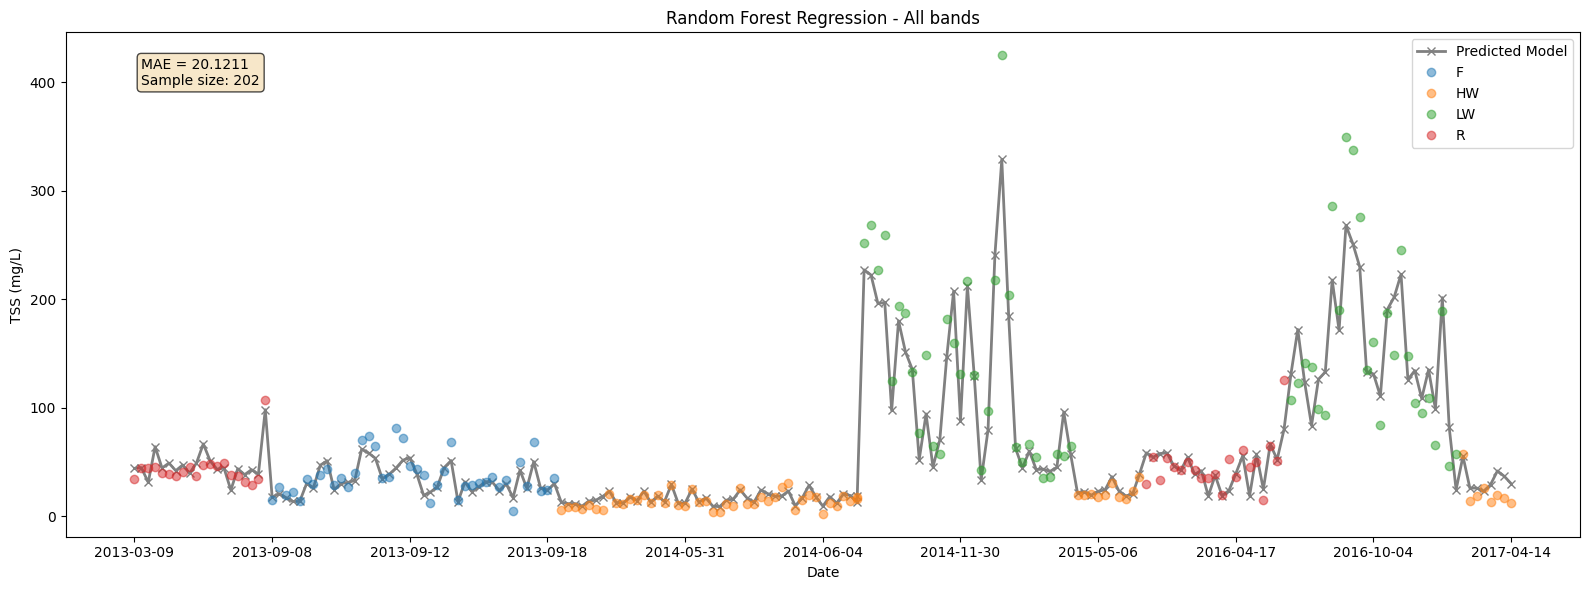

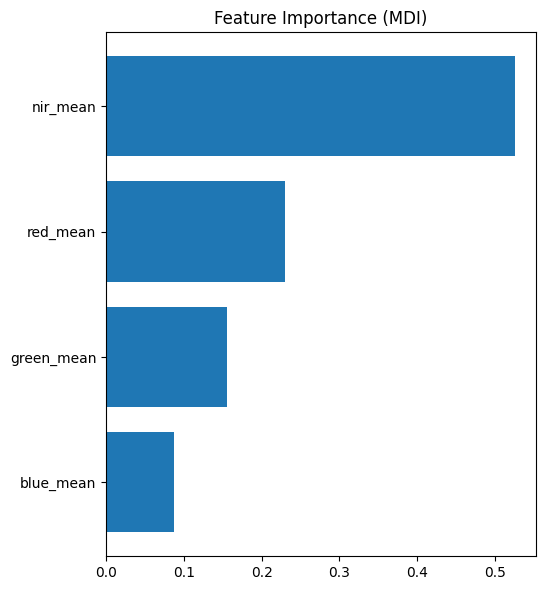

Random Forest Regression

Random Forest Regression - All bands + Lake Results
Training Metrics: {'r2': 0.9056505498509483, 'mae': 13.233800695426682, 'mse': 478.20571072845877, 'mape': 0.3005869144874474, 'exp_var': 0.9071215902935372}
CV Metrics: {'r2': 0.6790687042635206, 'mae': 20.603685786396994, 'mse': 1260.5243045656669, 'mape': 0.4575356059900474, 'exp_var': 0.687416053163018}


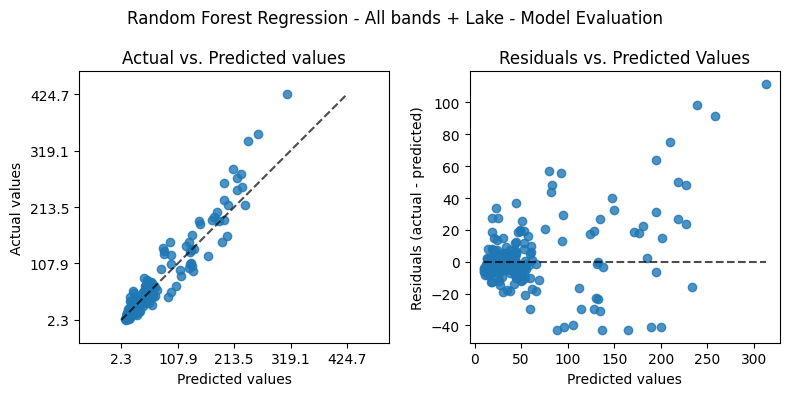

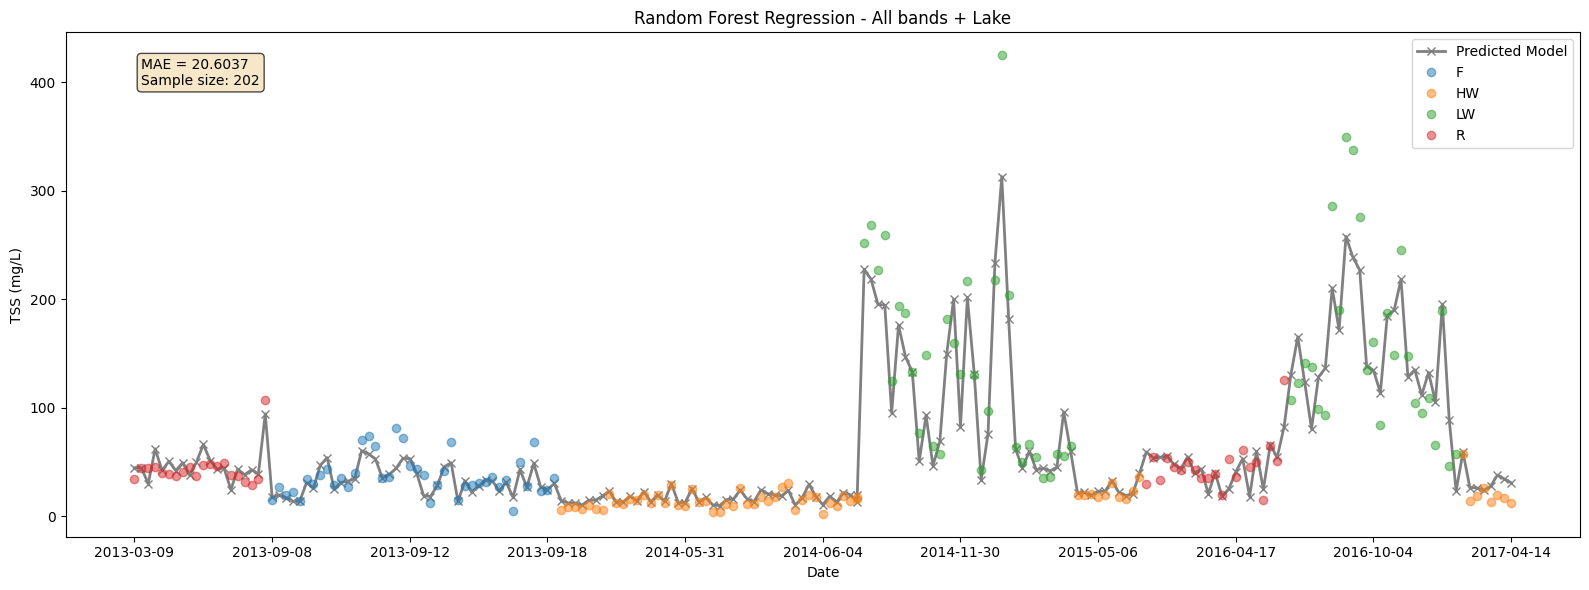

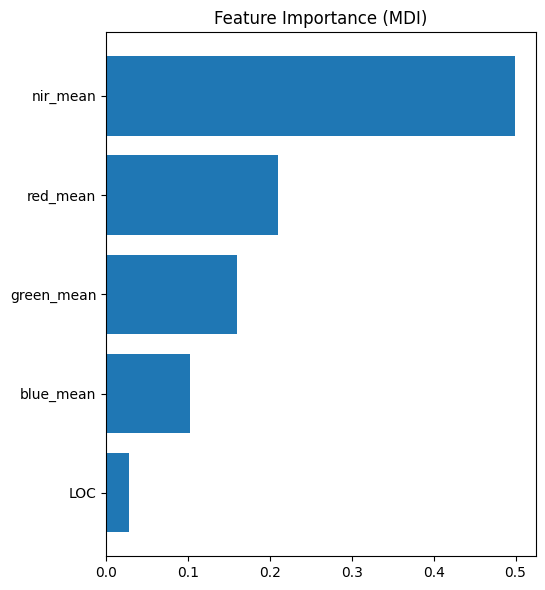

Random Forest Regression

Random Forest Regression - All bands + Water Period Results
Training Metrics: {'r2': 0.9583957761691622, 'mae': 7.757818437974753, 'mse': 210.86903415866541, 'mape': 0.143204832635682, 'exp_var': 0.9584678407357727}
CV Metrics: {'r2': 0.7159213946608242, 'mae': 18.079140755888382, 'mse': 1132.3620800896383, 'mape': 0.36050062152724094, 'exp_var': 0.7205238144044656}


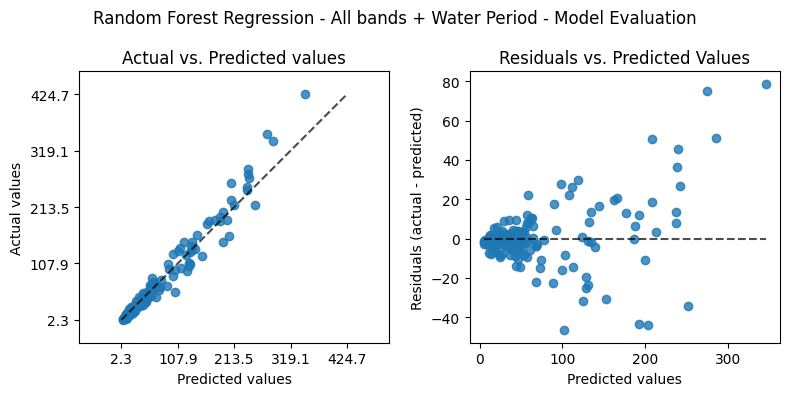

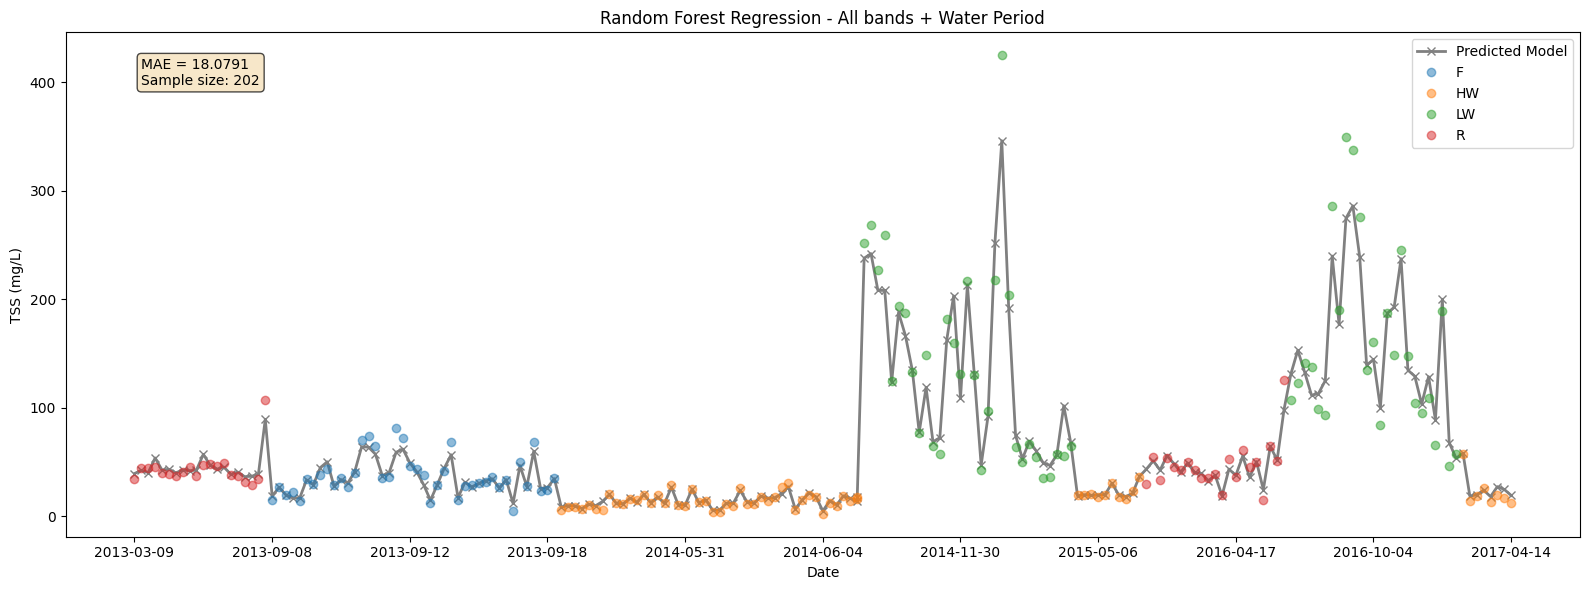

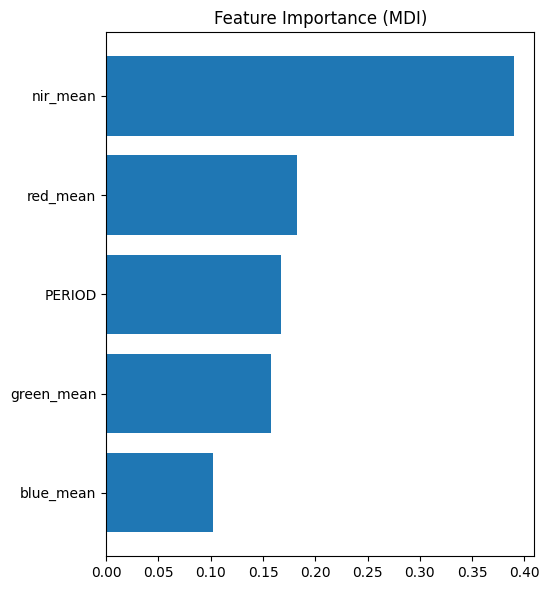

Random Forest Regression


In [ ]:
key = 'RF'
n_bands = 'multi_band'
model = get_model(key)
title = (MODEL_CONFIG[key]['description'])
# Feature Exploration
for feature_key,feature_info in FEATURE_GROUPS[n_bands].items():

    band = feature_info['band']
    name = feature_info['name']

    X = df_subset[band].copy()
    print(title)

    model_fit, y_pred, metrics, cv_metrics = train_and_evaluate_model(
            model=model,
            X=X, y=y,
            model_name=f"{title} - {name}",
            title = f"{title} - {name}",
            df_data=df_subset,
            exp = f"{feature_key}_{key}",
            impPlot = key
        )

    results['water_period']['model'][key][n_bands][feature_key] = {'metrics': metrics,'cv_metrics': cv_metrics,'params': model_fit.best_params_}
    results['water_period']['period_filter'] = None

### Export data

In [ ]:
df_metrics, df_cv_metrics = transform_dataframe(results)

In [ ]:
df_metrics.to_csv(os.path.join(export_dir,'RF_metrics.csv'))

df_cv_metrics.to_csv(os.path.join(export_dir,'RF_cv_metrics.csv'))

# Colab Export

In [ ]:
import shutil
import os

folder_to_zip = '/content/TSS Modeling'
output_zip_file = '/content/TSS_Modeling_zipped'

# Create a zip archive of the folder
shutil.make_archive(output_zip_file, 'zip', folder_to_zip)

print(f"Folder '{folder_to_zip}' has been zipped to '{output_zip_file}.zip'")